### **Problem:**
The company wants to automate the loan eligibility process (real-time) based on customer detail provided while filling out the online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem identifying the customer segments eligible for loan amounts to target these customers specifically. Here they have provided a partial data set.

Target = 'Loan_Status'

Problem Type = Classification

Goal = To Build Best model to automate loan eligiblity process

Who is the stakeholder? :
Bank

What is the risk? :
False_loan_approval

What is more dangerous: approving defaulter OR rejecting good customer?  :
approving defaulter

Which metric matters most? Recall? Precision? :
Precision of TP,least FP

In this project, the main focus is to reduce the risk of giving loans to the wrong applicants. If the company approves a high-risk customer, it can face financial loss. Because of this, reducing False Positives (Type 1 Errors) is very important. That is why Precision is used as a key evaluation metric, since it tells us how accurate the approved loan predictions are.

However, checking only precision is not enough. A good model should also balance risk and business growth. So, F1-score and ROC-AUC are also used to measure the overall performance of the model.

***Hypothesis Generation***

---



Loan_ID & Gender : Not significant values

Income Related
*   Higher Income - Higher Approval Chance
*   Lower Income or Higher Loan amount - Low Approval Chance

Credit Related
*   Higher Credit score - Higher chance of repay as well as higher approval chance
*   With no credit card - No past history of that applicant in bank, then lower approval chance

Married & Dependents

*   Married - Higher approval chance
*   Higher dependents - Lower approval chance bcz can have financial burden.

Education -
*   Higher Education level - High chance of job security then can repay loan , Approval chance high
*   Low Education - No job security , Less approval chance

Self_Employed
*   Self_employed - No fix income, lower chance
*   Employee - Fix Income, High approval chance

LoanAmount
*   Low Loan Amount - High approval chance
*   High Loan Amount - Low approval chance

Loan_Amount_Term
*   High Loan Duration - lower emi, low financal burden , High loan approval chance
*   Low duration - higher emi, high financial budern, Low approval chance

Property_Area
*   Urban area - high asset value, high approval chance
*   rural area - low asset value , low approval chance

### **Data Loading**
----------------------------------------------------------------

In [1]:
# Import necessary library
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler,Normalizer,MinMaxScaler,RobustScaler,PowerTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,f1_score,recall_score,precision_score,accuracy_score,roc_auc_score
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv(r'C:\Users\happy\Downloads\loan_sanction_train.csv')

In [4]:
print("Shape : ",df.shape)
print("Columns : ",df.columns)
print("Data_Types : \n",df.dtypes)
df.info()

Shape :  (614, 13)
Columns :  Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Data_Types : 
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married           

In [5]:
df.describe()
# We can clearly see outliers in column [ApplicantIncome,CoaaplicantIncome]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.describe(include="O")
# Non Duplicates = Loan_ID but not useful column
# Gender - Male & Female only bcz unique 2
# Married - Married or unmarried , Mostly Married
# Education - Graduate or Indermediate , mostly graduate
# Similary for rest

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


Categorical Columns =
Loan_ID	Gender	Married	Dependents	Education	Self_Employed	Property_Area	Loan_Status

Numerical Columns =
ApplicantIncome	CoapplicantIncome	LoanAmount	Loan_Amount_Term	Credit_History

In [7]:
Columns = list(df.columns)
Columns

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

## *EDA*
-------------------

In [8]:
# Checking for class imbalance
df['Loan_Status'].value_counts()
# Balanced Class

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [9]:
numerical_df = df.select_dtypes(include='number') # Numerical_columns_dataframe
cat_df = df.select_dtypes(exclude='number') # Categorical_Columns_dataframe

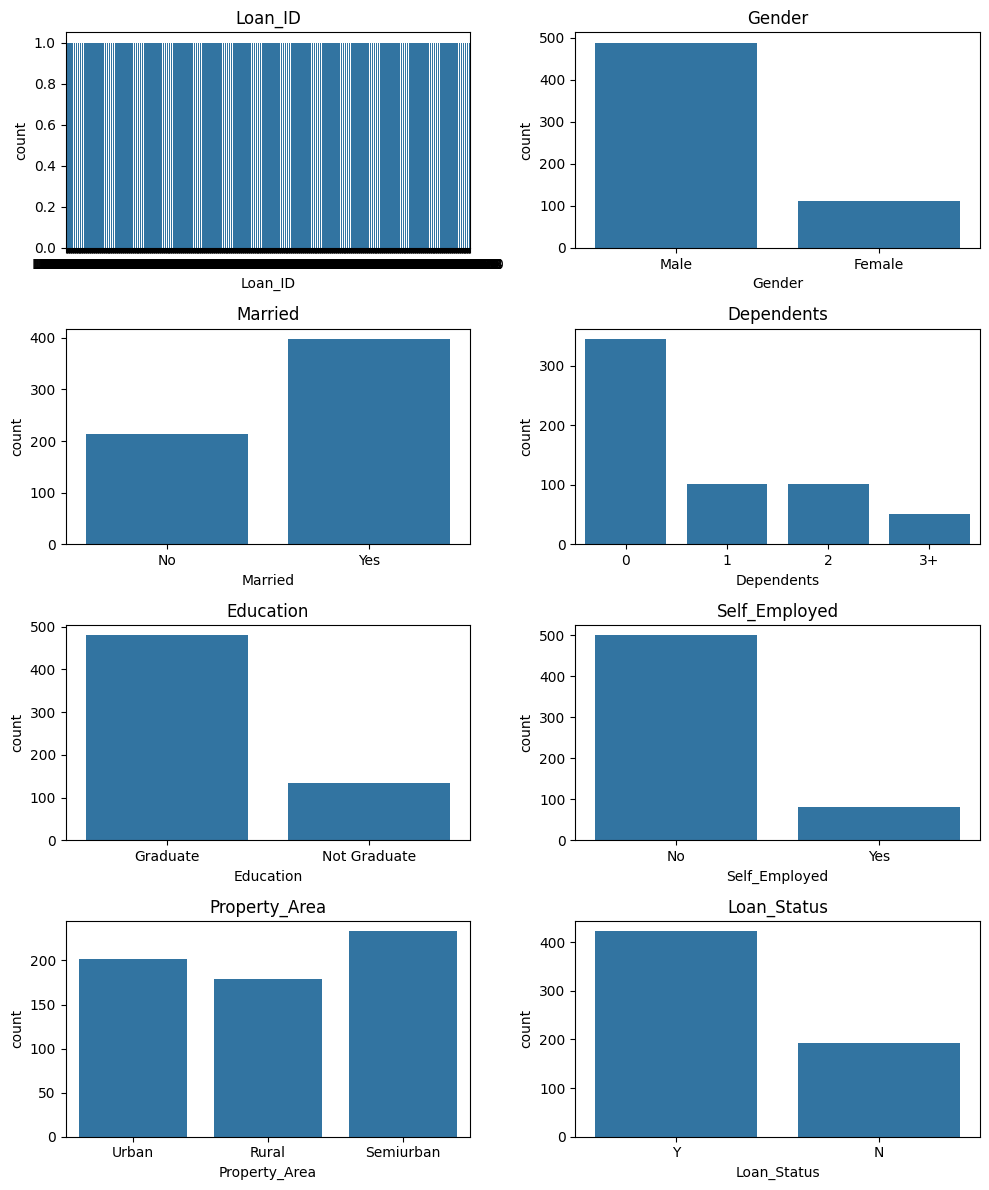

In [10]:
# Data_Overview
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()
for i,j in enumerate(cat_df.columns):
    sns.countplot(data=cat_df,x=j,ax=axes[i])
    axes[i].set_title(j)
plt.tight_layout()
plt.show()

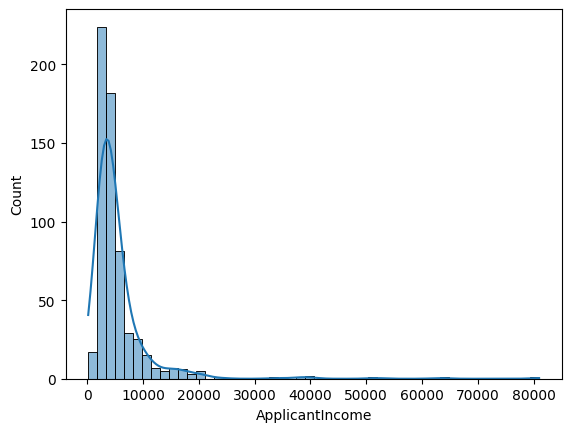

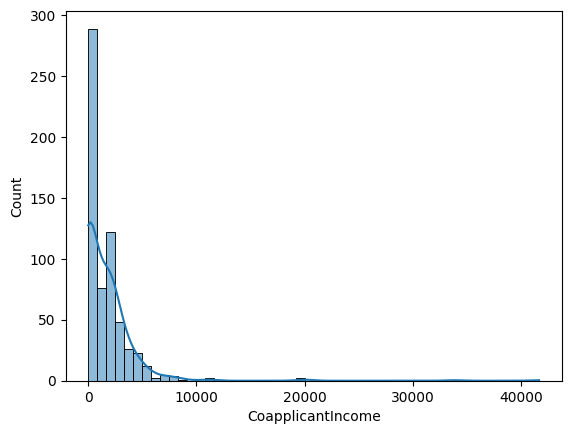

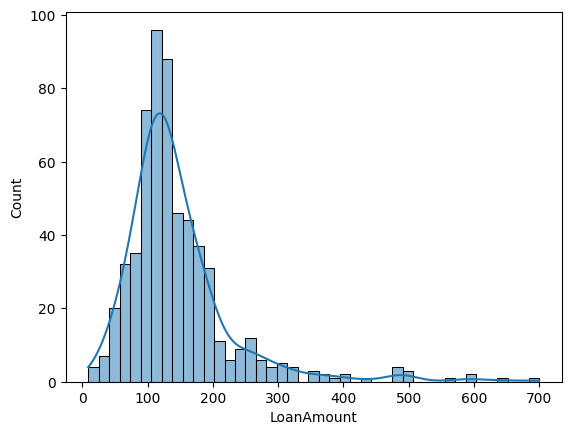

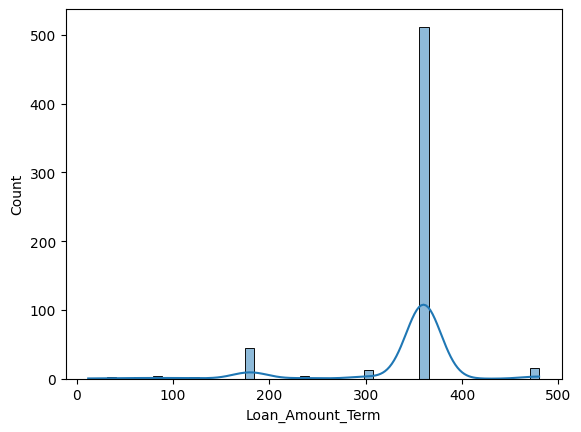

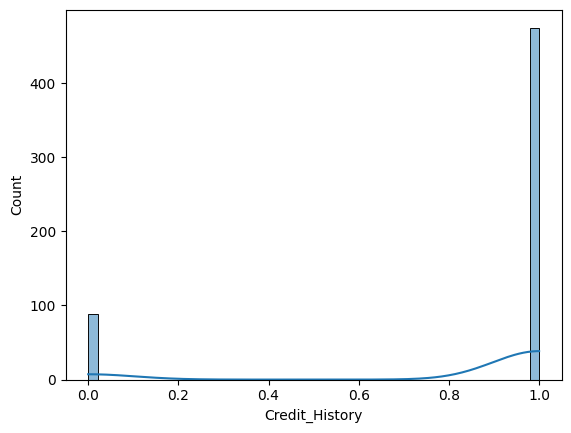

In [11]:
# Histogram for data_distribution,outliers,skewness
for i in numerical_df.columns:
  plt.figure()
  sns.histplot(data=numerical_df,x=numerical_df[i],kde=True)

Text(0.5, 1.0, 'Loan_Amount_Term')

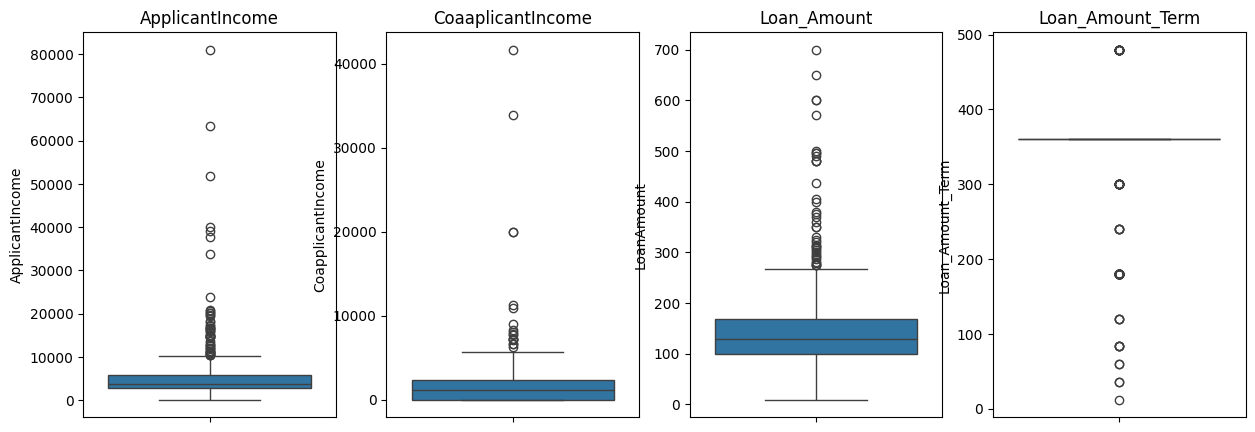

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=False)
sns.boxplot(y=numerical_df['ApplicantIncome'],ax=axes[0])
axes[0].set_title('ApplicantIncome')
sns.boxplot(y=numerical_df['CoapplicantIncome'],ax=axes[1])
axes[1].set_title('CoaaplicantIncome')
sns.boxplot(y=numerical_df['LoanAmount'],ax=axes[2])
axes[2].set_title('Loan_Amount')
sns.boxplot(y=numerical_df['Loan_Amount_Term'],ax=axes[3])
axes[3].set_title('Loan_Amount_Term')

**Loan_Amount & Loan approval relationship**

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

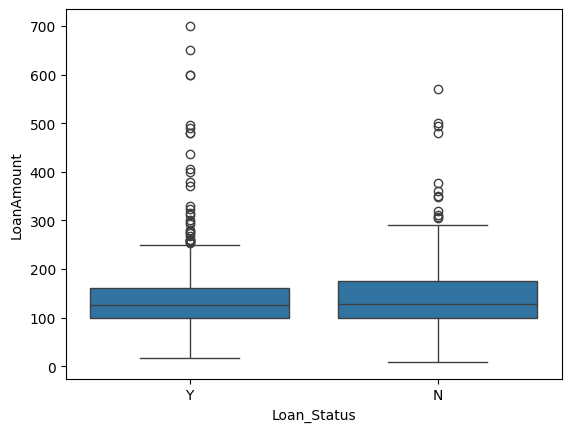

In [13]:
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)

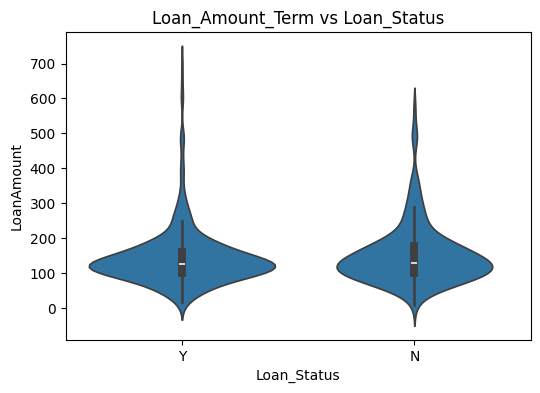

In [14]:
plt.figure(figsize=(6,4))
sns.violinplot(x='Loan_Status',y='LoanAmount',data=df)
plt.title('Loan_Amount_Term vs Loan_Status')
plt.show()

When amount<200 : ⬆Approvals ⬇Rejections

Amount>200 : ⬇Approvals ⬆Rejections expect some exceptence in Y bcz of high applicant or co-applicant income

Trend : Higher the loan_amount lower approval chance

In [15]:
# Making two dataframes based of their Loan_Status
approved_df = df[df['Loan_Status']=='Y']
unapproved_df = df[df['Loan_Status']=='N']

In [16]:
unapproved_df['Married'].value_counts().reset_index()

,Married,count
0,Yes,113
1,No,79


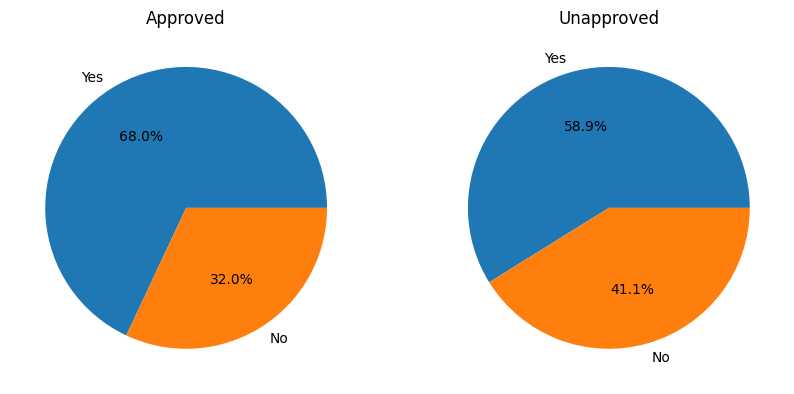

In [17]:

fig,axes = plt.subplots(1,2,figsize=(10,8))
axes[0].pie(approved_df['Married'].value_counts().reset_index().iloc[:,1],labels=approved_df['Married'].value_counts().reset_index().iloc[:,0],autopct="%1.1f%%")
axes[0].set_title('Approved')
axes[1].pie(unapproved_df['Married'].value_counts().reset_index().iloc[:,1],labels=unapproved_df['Married'].value_counts().reset_index().iloc[:,0],autopct="%1.1f%%")
axes[1].set_title('Unapproved')
plt.show()


As we can see in Approved loan, 68% married and remaining 32% Unmarried :

In Unapproved loan, 59% Married but 41% Unmarried

Approval chance goes higher if married
In rejected approval differences is Unmarried 32 -> 41%

Clearly showing it has significant impact in prediction

Impact of Loan duration on loan_status :

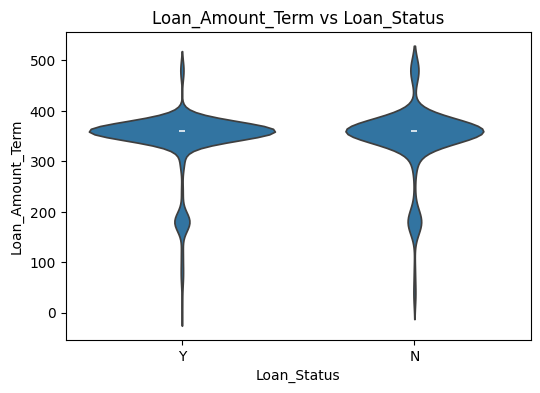

In [18]:
plt.figure(figsize=(6,4))
sns.violinplot(x='Loan_Status',y='Loan_Amount_Term',data=df)
plt.title('Loan_Amount_Term vs Loan_Status')
plt.show()

More approval chancees when it's b/w 300 to 400 after & before that range have more rejection.

In [19]:
#Impact of Credit_History in Loan_Status
# Bank have their history which shows its future purchasing power,past financial conditions,credit score,financial stability

In [20]:
pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index')

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.204211,0.795789


Major impact on both Loan approval and rejection probability

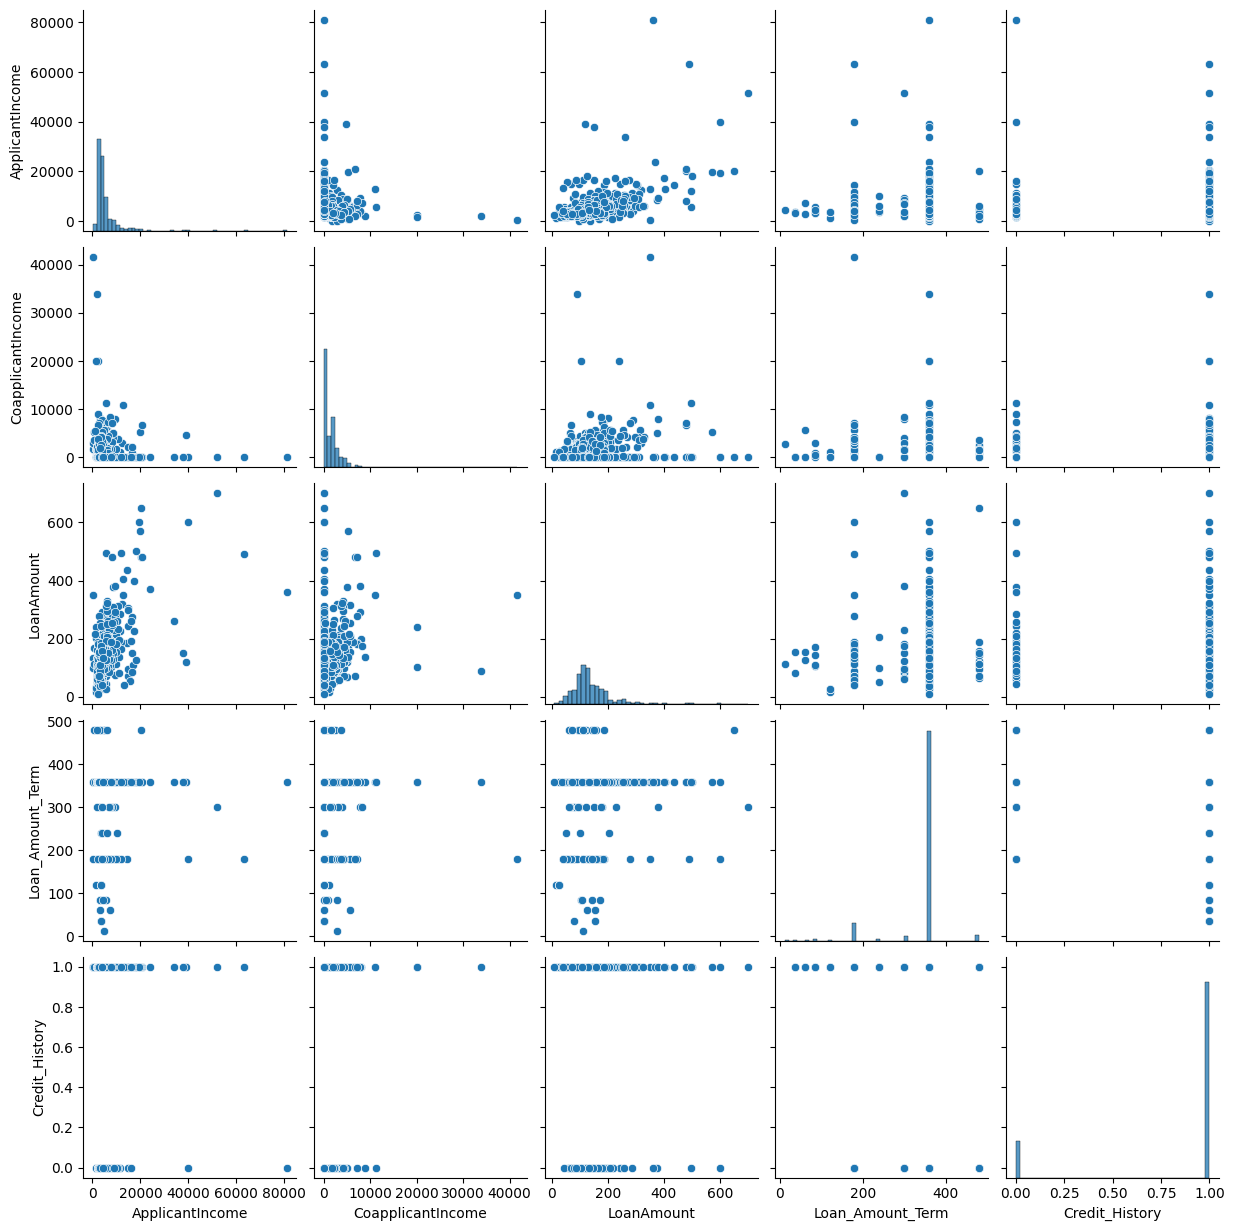

In [21]:
# Multivarient analysis
sns.pairplot(data=df)

## *Data_Cleaning*
--------------

In [22]:
# Data_Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [23]:
df.groupby('Gender').apply(lambda x: x.isnull().sum())

C:\Users\happy\AppData\Local\Temp\ipykernel_8308\1858245212.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Gender').apply(lambda x: x.isnull().sum())


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Gender,,,,,,,,,,,,,
Female,0,0,1,3,0,8,0,0,3,3,11,0,0
Male,0,0,2,12,0,24,0,0,19,11,38,0,0


In [24]:
df[df['Married'].isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,NaN,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [25]:
df.groupby('Gender')[['Married']].value_counts()

Gender  Married
Female  No          80
        Yes         31
Male    Yes        357
        No         130
Name: count, dtype: int64

In [26]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df.groupby('Gender')['Married'].transform(lambda x: x.mode()[0]))
df['Dependents'] = df['Dependents'].fillna(df.groupby('Gender')['Dependents'].transform(lambda x: x.mode()[0]))
df['Self_Employed'] = df['Self_Employed'].fillna(df.groupby('Gender')['Self_Employed'].transform(lambda x: x.mode()[0]))
df['Credit_History'] = df['Credit_History'].fillna(df.groupby('Gender')['Credit_History'].transform(lambda x: x.mode()[0]))
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df.groupby('Gender')['Loan_Amount_Term'].transform('mean'))
df['LoanAmount'] = df['LoanAmount'].fillna(df.groupby('Gender')['LoanAmount'].transform('mean'))

In [27]:
df['Dependents'] = df['Dependents'].str.replace(r'\D', '', regex=True).astype(int)

In [28]:
# Correct data_types
df['Gender']=df['Gender'].astype('category')
df['Education']=df['Education'].astype('category')
df['Self_Employed'] = df['Self_Employed'].astype('category')
df['Property_Area']=df['Property_Area'].astype('category')
df['Loan_Status']=df['Loan_Status'].astype('category')

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
# Data Transformation

In [31]:
df


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,150.861284,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [32]:
# unique of each columns
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           205
Loan_Amount_Term      12
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

## *Data Transformation(Encoding)*
---------------------------

In [33]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder,TargetEncoder

In [34]:
label = LabelEncoder()
OneHot = OneHotEncoder()
Ordinal = OrdinalEncoder()
Target = TargetEncoder()

In [35]:
# Encoding Decision:
# LabelEncoder : Gender,Married,Self_Employed,Loan_Status
# OnehotEncoder : Dependents
# OrdinalEncoder : Property_Area
# TargetEncoder : No need
# pandas map : Education bcz label uses alphabetical order but does change anything if I use label bcz just interpretation change

In [36]:
df = df.drop(columns=['Loan_ID']) # Having no importance

In [37]:
df['Education'].unique()

['Graduate', 'Not Graduate']
Categories (2, object): ['Graduate', 'Not Graduate']

In [38]:
df['Gender'] = label.fit_transform(df['Gender'])
df['Married'] = label.fit_transform(df['Married'])
df['Self_Employed']=label.fit_transform(df['Self_Employed'])
df['Loan_Status']=label.fit_transform(df['Loan_Status'])
onehot2 = OneHotEncoder(drop='first',sparse_output=False)
dependent_encoded = onehot2.fit_transform(df[['Dependents']])
x = pd.DataFrame(dependent_encoded,columns=onehot2.get_feature_names_out(['Dependents']),index=df.index)
ordinal2 = OrdinalEncoder(categories=[['Rural','Semiurban','Urban']])
df['Property_Area']=Ordinal.fit_transform(df[['Property_Area']])
df['Education'] = df['Education'].map({'Graduate':1,'Not Graduate':0})
#I encoded Gender,Married,Self_Employed,Loan_Status as binary because it has only two categories and no ordinal meaning. OneHotEncoding was unnecessary here.

In [39]:
df = pd.concat([df.drop(columns=['Dependents']),x], axis=1)

In [40]:
df

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Dependents_1,Dependents_2,Dependents_3
0,1,0,1,0,5849,0.0,150.861284,360.0,1.0,2.0,1,0.0,0.0,0.0
1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,0.0,0,1.0,0.0,0.0
2,1,1,1,1,3000,0.0,66.000000,360.0,1.0,2.0,1,0.0,0.0,0.0
3,1,1,0,0,2583,2358.0,120.000000,360.0,1.0,2.0,1,0.0,0.0,0.0
4,1,0,1,0,6000,0.0,141.000000,360.0,1.0,2.0,1,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,2900,0.0,71.000000,360.0,1.0,0.0,1,0.0,0.0,0.0
610,1,1,1,0,4106,0.0,40.000000,180.0,1.0,0.0,1,0.0,0.0,1.0
611,1,1,1,0,8072,240.0,253.000000,360.0,1.0,2.0,1,1.0,0.0,0.0
612,1,1,1,0,7583,0.0,187.000000,360.0,1.0,2.0,1,0.0,1.0,0.0


## *Data Spliting*
-------------------

In [41]:
# Data_spliting
# importing main libarires

In [42]:
from sklearn.model_selection import train_test_split as tts,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MaxAbsScaler,PowerTransformer,StandardScaler,RobustScaler,MinMaxScaler,Normalizer
from sklearn.metrics import classification_report,accuracy_score,f1_score,confusion_matrix,precision_score
# Creating useful Objects:
KNN = KNeighborsClassifier()
LR = LogisticRegression()
DT = DecisionTreeClassifier()
maxab_scl = MaxAbsScaler()
standard_scl = StandardScaler()
robust_scl = RobustScaler()
normalizer_scl = Normalizer()
ptf_scl = PowerTransformer()

In [43]:
x = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']
x_train,x_test,y_train,y_test = tts(x,y,test_size=0.3,random_state=42)

## *Scalling*
--------------------------

Creating different scaled dataframe which helps us to find best scaler which give us best result

In [44]:
x_train_maxab_scl = maxab_scl.fit_transform(x_train)
x_train_maxab_scl = pd.DataFrame(x_train_maxab_scl,columns=x_train.columns)
x_train_standard_scl = standard_scl.fit_transform(x_train)
x_train_standard_scl = pd.DataFrame(x_train_standard_scl,columns = x_train.columns)
x_train_robust_scl = robust_scl.fit_transform(x_train)
x_train_robust_scl = pd.DataFrame(x_train_robust_scl,columns= x_train.columns)
x_train_normalizer_scl = normalizer_scl.fit_transform(x_train)
x_train_normalizer_scl = pd.DataFrame(x_train_normalizer_scl,columns=x_train.columns)
x_train_ptf_scl = ptf_scl.fit_transform(x_train)
x_train_ptf_scl = pd.DataFrame(x_train_ptf_scl,columns = x_train.columns)

In [45]:
"""scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
for i,j in enumerate(scaled_x_train):
  globals()[f'model_logistic_scaled{i+1}'] = LR.fit(j,y_train)"""

"scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]\nfor i,j in enumerate(scaled_x_train):\n  globals()[f'model_logistic_scaled{i+1}'] = LR.fit(j,y_train)"

## *Model Training* 
-----------------------

#### **Model 1st : Logistic Classifier**

---



In [46]:
scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
models = {}
for name, j in zip(["maxabs", "standard", "robust", "normalizer", "powertransform"],scaled_x_train):
    model = LogisticRegression()
    model.fit(j, y_train)
    models[name] = model

c:\Users\happy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
x_test_maxab_scl = maxab_scl.transform(x_test)
x_test_maxab_scl = pd.DataFrame(x_test_maxab_scl,columns=x_test.columns)
x_test_standard_scl = standard_scl.transform(x_test)
x_test_standard_scl = pd.DataFrame(x_test_standard_scl,columns = x_test.columns)
x_test_robust_scl = robust_scl.transform(x_test)
x_test_robust_scl = pd.DataFrame(x_test_robust_scl,columns= x_test.columns)
x_test_normalizer_scl = normalizer_scl.transform(x_test)
x_test_normalizer_scl = pd.DataFrame(x_test_normalizer_scl,columns=x_test.columns)
x_test_ptf_scl = ptf_scl.transform(x_test)
x_test_ptf_scl = pd.DataFrame(x_test_ptf_scl,columns = x_test.columns)

Check result of logistic classifier model trained on different scaled data

In [48]:
y_pred_maxabs = models["maxabs"].predict(x_test_maxab_scl)

In [49]:
import warnings
warnings.filterwarnings("ignore")

In [50]:
print(classification_report(y_test,y_pred_maxabs))
print(accuracy_score(y_test,y_pred_maxabs))

              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

0.7837837837837838


In [51]:
y_pred_standard = models['standard'].predict(x_test_standard_scl)

In [52]:
print(classification_report(y_test,y_pred_standard))
print(confusion_matrix(y_test,y_pred_standard))
print(accuracy_score(y_test,y_pred_standard))

              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

[[ 27  38]
 [  2 118]]
0.7837837837837838


In [53]:
y_pred_robust = models['robust'].predict(x_test_robust_scl)
print(classification_report(y_test,y_pred_robust))
print(confusion_matrix(y_test,y_pred_robust))
print(accuracy_score(y_test,y_pred_robust))

              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

[[ 27  38]
 [  2 118]]
0.7837837837837838


In [54]:
y_pred_normalizer = models["normalizer"].predict(x_test_normalizer_scl)
print(classification_report(y_test,y_pred_normalizer))
print(confusion_matrix(y_test,y_pred_normalizer))
print(accuracy_score(y_test,y_pred_normalizer))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.65      1.00      0.79       120

    accuracy                           0.65       185
   macro avg       0.32      0.50      0.39       185
weighted avg       0.42      0.65      0.51       185

[[  0  65]
 [  0 120]]
0.6486486486486487


In [55]:
y_pred_ptf = models["powertransform"].predict(x_test_ptf_scl)
print(classification_report(y_test,y_pred_ptf))
print(confusion_matrix(y_test,y_pred_ptf))
print(accuracy_score(y_test,y_pred_ptf))

              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

[[ 27  38]
 [  2 118]]
0.7837837837837838


In [56]:
# Best model from Logistic using different scaler we got:
model_logistic_wo = models['powertransform']
y_pred_logistic_wo = y_pred_ptf

### Model2 KNN

In [57]:
scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
models = {}
for name, j in zip(["maxabs", "standard", "robust", "normalizer", "powertransform"],scaled_x_train):
    model = KNeighborsClassifier()
    model.fit(j, y_train)
    models[name] = model

Check result of KNN classifier model trained on different scalled data

In [58]:
# Same steps as in Logistic classifier

In [59]:
y_pred_maxabs = models["maxabs"].predict(x_test_maxab_scl)
print('\nMaxab_scalled: \n',classification_report(y_test,y_pred_maxabs))
print(confusion_matrix(y_test,y_pred_maxabs))
print(accuracy_score(y_test,y_pred_maxabs))
y_pred_standard = models['standard'].predict(x_test_standard_scl)
print('\nStandardScalled :\n',classification_report(y_test,y_pred_standard))
print(confusion_matrix(y_test,y_pred_standard))
print(accuracy_score(y_test,y_pred_standard))
y_pred_robust = models['robust'].predict(x_test_robust_scl)
print('\nRobust: \n',classification_report(y_test,y_pred_robust))
print(confusion_matrix(y_test,y_pred_robust))
print(accuracy_score(y_test,y_pred_robust))
y_pred_normalizer = models["normalizer"].predict(x_test_normalizer_scl)
print('\nNormalizer: \n',classification_report(y_test,y_pred_normalizer))
print(confusion_matrix(y_test,y_pred_normalizer))
print(accuracy_score(y_test,y_pred_normalizer))
y_pred_ptf = models["powertransform"].predict(x_test_ptf_scl)
print('\nPowerTransformer: \n',classification_report(y_test,y_pred_ptf))
print(confusion_matrix(y_test,y_pred_ptf))
print(accuracy_score(y_test,y_pred_ptf))


Maxab_scalled: 
               precision    recall  f1-score   support

           0       0.73      0.42      0.53        65
           1       0.74      0.92      0.82       120

    accuracy                           0.74       185
   macro avg       0.74      0.67      0.68       185
weighted avg       0.74      0.74      0.72       185

[[ 27  38]
 [ 10 110]]
0.7405405405405405

StandardScalled :
               precision    recall  f1-score   support

           0       0.78      0.38      0.52        65
           1       0.74      0.94      0.83       120

    accuracy                           0.75       185
   macro avg       0.76      0.66      0.67       185
weighted avg       0.75      0.75      0.72       185

[[ 25  40]
 [  7 113]]
0.745945945945946

Robust: 
               precision    recall  f1-score   support

           0       0.68      0.26      0.38        65
           1       0.70      0.93      0.80       120

    accuracy                           0.70       

In [60]:
# Best model from KNN:
model_knn_wo = models['standard']
y_pred_knn_wo = y_pred_standard
# Bcz in financial risk prediction, false positives (approving risky applicants) may lead to financial losses. Therefore, precision is considered alongside recall while selecting the final model.

### Model3 Decision Tree

In [61]:
scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
models = {}
for name, j in zip(["maxabs", "standard", "robust", "normalizer", "powertransform"],scaled_x_train):
    model = DecisionTreeClassifier()
    model.fit(j, y_train)
    models[name] = model

In [62]:
y_pred_maxabs = models["maxabs"].predict(x_test_maxab_scl)
print('\nMaxab_scalled: \n',classification_report(y_test,y_pred_maxabs))
print(confusion_matrix(y_test,y_pred_maxabs))
print(accuracy_score(y_test,y_pred_maxabs))
y_pred_standard = models['standard'].predict(x_test_standard_scl)
print('\nStandardScalled :\n',classification_report(y_test,y_pred_standard))
print(confusion_matrix(y_test,y_pred_standard))
print(accuracy_score(y_test,y_pred_standard))
y_pred_robust = models['robust'].predict(x_test_robust_scl)
print('\nRobust: \n',classification_report(y_test,y_pred_robust))
print(confusion_matrix(y_test,y_pred_robust))
print(accuracy_score(y_test,y_pred_robust))
y_pred_normalizer = models["normalizer"].predict(x_test_normalizer_scl)
print('\nNormalizer: \n',classification_report(y_test,y_pred_normalizer))
print(confusion_matrix(y_test,y_pred_normalizer))
print(accuracy_score(y_test,y_pred_normalizer))
y_pred_ptf = models["powertransform"].predict(x_test_ptf_scl)
print('\nPowerTransformer: \n',classification_report(y_test,y_pred_ptf))
print(confusion_matrix(y_test,y_pred_ptf))
print(accuracy_score(y_test,y_pred_ptf))


Maxab_scalled: 
               precision    recall  f1-score   support

           0       0.55      0.51      0.53        65
           1       0.74      0.78      0.76       120

    accuracy                           0.68       185
   macro avg       0.65      0.64      0.64       185
weighted avg       0.68      0.68      0.68       185

[[33 32]
 [27 93]]
0.6810810810810811

StandardScalled :
               precision    recall  f1-score   support

           0       0.55      0.46      0.50        65
           1       0.73      0.79      0.76       120

    accuracy                           0.68       185
   macro avg       0.64      0.63      0.63       185
weighted avg       0.67      0.68      0.67       185

[[30 35]
 [25 95]]
0.6756756756756757

Robust: 
               precision    recall  f1-score   support

           0       0.51      0.43      0.47        65
           1       0.72      0.78      0.74       120

    accuracy                           0.65       185
   


Normalizer: 
               precision    recall  f1-score   support

           0       0.60      0.48      0.53        65
           1       0.74      0.82      0.78       120

    accuracy                           0.70       185
   macro avg       0.67      0.65      0.66       185
weighted avg       0.69      0.70      0.69       185

[[31 34]
 [21 99]]
0.7027027027027027

PowerTransformer: 
               precision    recall  f1-score   support

           0       0.56      0.46      0.50        65
           1       0.73      0.80      0.76       120

    accuracy                           0.68       185
   macro avg       0.64      0.63      0.63       185
weighted avg       0.67      0.68      0.67       185

[[30 35]
 [24 96]]
0.6810810810810811


In [63]:
# extracting best DT model:
model_dt_wo = models['normalizer']
y_pred_dt_wo = y_pred_ptf # predicted y by DT before Feature Engineering and outlier removals

## *Model Evaluation*
-------------------------

### After Feature Engineering & Removing Outliers model performance

In [64]:
numerical_df.sample(5) # View numerical_df
numerical_df.drop(columns=['Credit_History'],inplace=True)  # Credit_History is categorical columns but at raw data it were in binary numbers

In [65]:
for i in numerical_df:
  # Outliers detection by help of IQR_method :
  q1 =numerical_df[i].quantile(0.25)
  q3 =numerical_df[i].quantile(0.75)
  iqr = q3-q1
  upper_bound = q3+1.5*iqr
  lower_bound = q1-1.5*iqr
  outlier =numerical_df[(numerical_df[i]<lower_bound)|(numerical_df[i]>upper_bound)]
  print(f'{i} Outliers :')
  print(len(outlier))
  # By help of Std_rule:
  mean =numerical_df[i].mean()
  std =numerical_df[i].std()
  lower_bound = mean-(3*std)
  upper_bound = mean+(3*std)
  Outliers =numerical_df[(numerical_df[i]<lower_bound)|(numerical_df[i]>upper_bound)]
  print(f"{i} Outliers by std_rule : ")
  print(len(Outliers))

ApplicantIncome Outliers :
50
ApplicantIncome Outliers by std_rule : 
8
CoapplicantIncome Outliers :
18
CoapplicantIncome Outliers by std_rule : 
6
LoanAmount Outliers :
39
LoanAmount Outliers by std_rule : 
14
Loan_Amount_Term Outliers :
88
Loan_Amount_Term Outliers by std_rule : 
12


In [66]:
# LoanAmount Distribution with IQR references

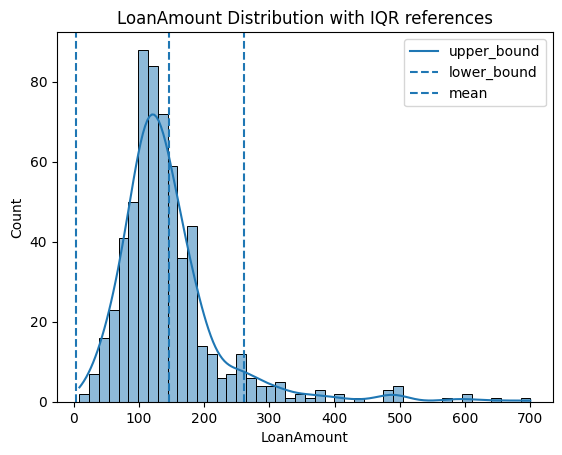

In [67]:
q1=df['LoanAmount'].quantile(0.25)
q3=df['LoanAmount'].quantile(0.75)
iqr=q3-q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
mean=df['LoanAmount'].mean()  # Gives mean_value
sns.histplot(data=df,x='LoanAmount',kde=True)
# Adding reference lines
plt.axvline(mean,linestyle='--')
plt.axvline(upper_bound,linestyle='--')
plt.axvline(lower_bound,linestyle='--')
plt.title("LoanAmount Distribution with IQR references")
plt.legend(["upper_bound","lower_bound","mean"])
plt.ylabel('Count')
plt.show()



##### Since income and loan amount represent valid financial variations rather than data errors, outliers were not removed.
Instead, log transformation will applied to reduce skewness and improve model performance.

In [68]:
# Feature Engineering
df['Total_Income']= df['ApplicantIncome']+df['CoapplicantIncome']
""" Since we have two different column ApplicantIncome & Co-applicanticome of same applicant,
which could be consider as single feature as Total_Income which makes sense and less noises for model,
may increase model accuracy"""

' Since we have two different column ApplicantIncome & Co-applicanticome of same applicant,\nwhich could be consider as single feature as Total_Income which makes sense and less noises for model,\nmay increase model accuracy'

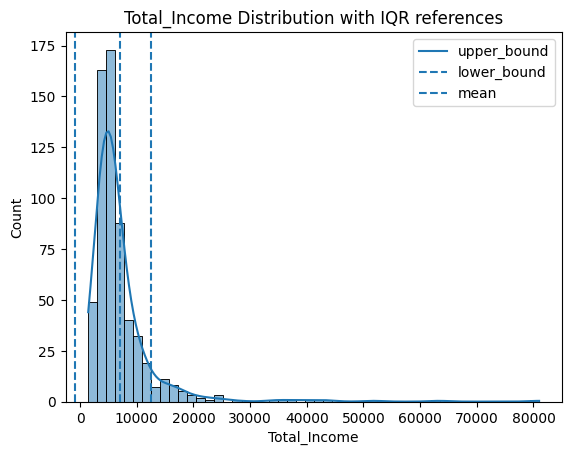

In [69]:
# Visualization of skewness of Total_Income feature
q1=df['Total_Income'].quantile(0.25)
q3=df['Total_Income'].quantile(0.75)
iqr=q3-q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
mean=df['Total_Income'].mean()  # Gives mean_value
sns.histplot(data=df,x='Total_Income',kde=True)
# Adding reference lines
plt.axvline(mean,linestyle='--')
plt.axvline(upper_bound,linestyle='--')
plt.axvline(lower_bound,linestyle='--')
plt.title("Total_Income Distribution with IQR references")
plt.legend(["upper_bound","lower_bound","mean"])
plt.ylabel('Count')
plt.show()

In [70]:
print("Skew : ",df['Total_Income'].skew())

Skew :  5.633448514884535


In [71]:
# Applying log transformation to Total_Income & creating new column Total_Income_log
df['Total_Income_log'] = np.log1p(df['Total_Income']) # Best for right skew
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

In [72]:
# Skewness differences before log transformation and after
print("Before Skew:", df['Total_Income'].skew())
print("After Skew:", df['Total_Income_log'].skew())

Before Skew: 5.633448514884535
After Skew: 1.077048263350872


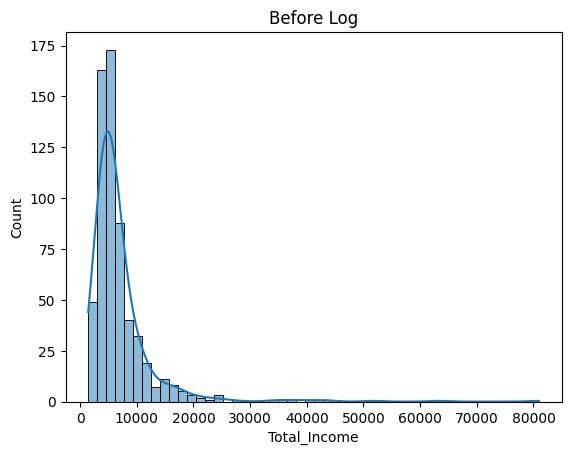

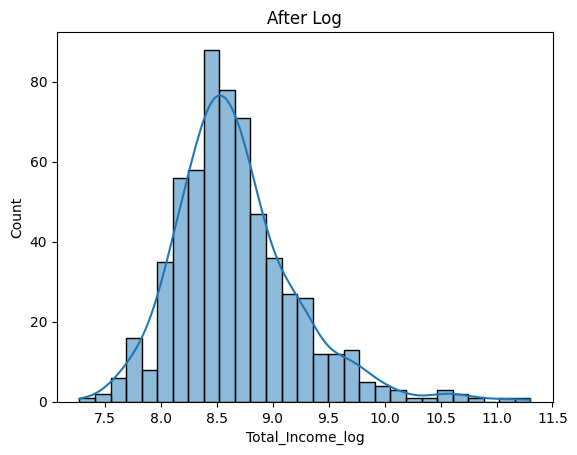

In [73]:
# Quick Visual check:
sns.histplot(df['Total_Income'],kde=True)
plt.title("Before Log")
plt.show()
sns.histplot(df['Total_Income_log'],kde=True)
plt.title("After Log")
plt.show()

In [74]:
# Drop unnecessary features/columns
df.drop(columns=['ApplicantIncome','Total_Income','CoapplicantIncome','LoanAmount'],inplace=True)

Now we will continue same steps as we already did in upper segments , but now without outliers or skewed features

Let's see model scoring :

In [75]:
x = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']
x_train,x_test,y_train,y_test = tts(x,y,test_size=0.3,random_state=42)
# Creating different scaled dataframe which helps us to find best scaler which give us best result
x_train_maxab_scl = maxab_scl.fit_transform(x_train)
x_train_maxab_scl = pd.DataFrame(x_train_maxab_scl,columns=x_train.columns)
x_train_standard_scl = standard_scl.fit_transform(x_train)
x_train_standard_scl = pd.DataFrame(x_train_standard_scl,columns = x_train.columns)
x_train_robust_scl = robust_scl.fit_transform(x_train)
x_train_robust_scl = pd.DataFrame(x_train_robust_scl,columns= x_train.columns)
x_train_normalizer_scl = normalizer_scl.fit_transform(x_train)
x_train_normalizer_scl = pd.DataFrame(x_train_normalizer_scl,columns=x_train.columns)
x_train_ptf_scl = ptf_scl.fit_transform(x_train)
x_train_ptf_scl = pd.DataFrame(x_train_ptf_scl,columns = x_train.columns)


#### **Model 1st : Logistic Classifier**

---



In [76]:
scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
models = {}
for name, j in zip(["maxabs", "standard", "robust", "normalizer", "powertransform"],scaled_x_train):
    model = LogisticRegression()
    model.fit(j, y_train)
    models[name] = model
x_test_maxab_scl = maxab_scl.transform(x_test)
x_test_maxab_scl = pd.DataFrame(x_test_maxab_scl,columns=x_test.columns)
x_test_standard_scl = standard_scl.transform(x_test)
x_test_standard_scl = pd.DataFrame(x_test_standard_scl,columns = x_test.columns)
x_test_robust_scl = robust_scl.transform(x_test)
x_test_robust_scl = pd.DataFrame(x_test_robust_scl,columns= x_test.columns)
x_test_normalizer_scl = normalizer_scl.transform(x_test)
x_test_normalizer_scl = pd.DataFrame(x_test_normalizer_scl,columns=x_test.columns)
x_test_ptf_scl = ptf_scl.transform(x_test)
x_test_ptf_scl = pd.DataFrame(x_test_ptf_scl,columns = x_test.columns)
y_pred_maxabs = models["maxabs"].predict(x_test_maxab_scl)
print('\nMaxab_scalled: \n',classification_report(y_test,y_pred_maxabs))
print(confusion_matrix(y_test,y_pred_maxabs))
print(accuracy_score(y_test,y_pred_maxabs))
y_pred_standard = models['standard'].predict(x_test_standard_scl)
print('\nStandardScalled :\n',classification_report(y_test,y_pred_standard))
print(confusion_matrix(y_test,y_pred_standard))
print(accuracy_score(y_test,y_pred_standard))
y_pred_robust = models['robust'].predict(x_test_robust_scl)
print('\nRobust: \n',classification_report(y_test,y_pred_robust))
print(confusion_matrix(y_test,y_pred_robust))
print(accuracy_score(y_test,y_pred_robust))
y_pred_normalizer = models["normalizer"].predict(x_test_normalizer_scl)
print('\nNormalizer: \n',classification_report(y_test,y_pred_normalizer))
print(confusion_matrix(y_test,y_pred_normalizer))
print(accuracy_score(y_test,y_pred_normalizer))
y_pred_ptf = models["powertransform"].predict(x_test_ptf_scl)
print('\nPowerTransformer: \n',classification_report(y_test,y_pred_ptf))
print(confusion_matrix(y_test,y_pred_ptf))
print(accuracy_score(y_test,y_pred_ptf))



Maxab_scalled: 
               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

[[ 27  38]
 [  2 118]]
0.7837837837837838

StandardScalled :
               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

[[ 27  38]
 [  2 118]]
0.7837837837837838

Robust: 
               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78      

In [77]:
# Extracting best model with least false_positives
model_logistic = models['powertransform']
y_pred_logis = y_pred_ptf
auc = roc_auc_score(y_test,y_pred_ptf)
print("ROC-AUC:", auc)

ROC-AUC: 0.7070512820512821


### Model2 KNN

In [78]:
scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
models = {}
for name, j in zip(["maxabs", "standard", "robust", "normalizer", "powertransform"],scaled_x_train):
    model = KNeighborsClassifier()
    model.fit(j, y_train)
    models[name] = model

In [79]:
y_pred_maxabs = models["maxabs"].predict(x_test_maxab_scl)
print('\nMaxab_scalled: \n',classification_report(y_test,y_pred_maxabs))
print(confusion_matrix(y_test,y_pred_maxabs))
print(accuracy_score(y_test,y_pred_maxabs))
y_pred_standard = models['standard'].predict(x_test_standard_scl)
print('\nStandardScalled :\n',classification_report(y_test,y_pred_standard))
print(confusion_matrix(y_test,y_pred_standard))
print(accuracy_score(y_test,y_pred_standard))
y_pred_robust = models['robust'].predict(x_test_robust_scl)
print('\nRobust: \n',classification_report(y_test,y_pred_robust))
print(confusion_matrix(y_test,y_pred_robust))
print(accuracy_score(y_test,y_pred_robust))
y_pred_normalizer = models["normalizer"].predict(x_test_normalizer_scl)
print('\nNormalizer: \n',classification_report(y_test,y_pred_normalizer))
print(confusion_matrix(y_test,y_pred_normalizer))
print(accuracy_score(y_test,y_pred_normalizer))
y_pred_ptf = models["powertransform"].predict(x_test_ptf_scl)
print('\nPowerTransformer: \n',classification_report(y_test,y_pred_ptf))
print(confusion_matrix(y_test,y_pred_ptf))
print(accuracy_score(y_test,y_pred_ptf))


Maxab_scalled: 
               precision    recall  f1-score   support

           0       0.76      0.43      0.55        65
           1       0.75      0.93      0.83       120

    accuracy                           0.75       185
   macro avg       0.75      0.68      0.69       185
weighted avg       0.75      0.75      0.73       185

[[ 28  37]
 [  9 111]]
0.7513513513513513

StandardScalled :
               precision    recall  f1-score   support

           0       0.71      0.37      0.48        65
           1       0.73      0.92      0.81       120

    accuracy                           0.72       185
   macro avg       0.72      0.64      0.65       185
weighted avg       0.72      0.72      0.70       185

[[ 24  41]
 [ 10 110]]
0.7243243243243244

Robust: 
               precision    recall  f1-score   support

           0       0.69      0.37      0.48        65
           1       0.73      0.91      0.81       120

    accuracy                           0.72      

In [80]:
# Best Model from KNN:
# Final Selected Model:
model_knn = models['maxabs']
y_pred_maxabs_knn = y_pred_maxabs
"""This KNN configuration delivered the strongest overall performance.
It recorded the highest accuracy within the KNN group, minimized false positives, maintained balanced performance across classes (macro average),
 and showed comparatively better detection of rejected loan cases (class 0)."""

'This KNN configuration delivered the strongest overall performance.\nIt recorded the highest accuracy within the KNN group, minimized false positives, maintained balanced performance across classes (macro average),\n and showed comparatively better detection of rejected loan cases (class 0).'

### Model3 Decision Tree


---



In [81]:
scaled_x_train = [x_train_maxab_scl,x_train_standard_scl,x_train_robust_scl,x_train_normalizer_scl,x_train_ptf_scl]
models = {}
for name, j in zip(["maxabs", "standard", "robust", "normalizer", "powertransform"],scaled_x_train):
    model = DecisionTreeClassifier()
    model.fit(j, y_train)
    models[name] = model

In [82]:
y_pred_maxabs = models["maxabs"].predict(x_test_maxab_scl)
print('\nMaxab_scalled: \n',classification_report(y_test,y_pred_maxabs))
print(accuracy_score(y_test,y_pred_maxabs))
y_pred_standard = models['standard'].predict(x_test_standard_scl)
print('\nStandardScalled :\n',classification_report(y_test,y_pred_standard))
print(confusion_matrix(y_test,y_pred_standard))
print(accuracy_score(y_test,y_pred_standard))
y_pred_robust = models['robust'].predict(x_test_robust_scl)
print('\nRobust: \n',classification_report(y_test,y_pred_robust))
print(confusion_matrix(y_test,y_pred_robust))
print(accuracy_score(y_test,y_pred_robust))
y_pred_normalizer = models["normalizer"].predict(x_test_normalizer_scl)
print('\nNormalizer: \n',classification_report(y_test,y_pred_normalizer))
print(confusion_matrix(y_test,y_pred_normalizer))
print(accuracy_score(y_test,y_pred_normalizer))
y_pred_ptf = models["powertransform"].predict(x_test_ptf_scl)
print('\nPowerTransformer: \n',classification_report(y_test,y_pred_ptf))
print(confusion_matrix(y_test,y_pred_ptf))
print(accuracy_score(y_test,y_pred_ptf))


Maxab_scalled: 
               precision    recall  f1-score   support

           0       0.56      0.62      0.58        65
           1       0.78      0.73      0.76       120

    accuracy                           0.69       185
   macro avg       0.67      0.67      0.67       185
weighted avg       0.70      0.69      0.70       185

0.6918918918918919

StandardScalled :
               precision    recall  f1-score   support

           0       0.54      0.60      0.57        65
           1       0.77      0.72      0.75       120

    accuracy                           0.68       185
   macro avg       0.66      0.66      0.66       185
weighted avg       0.69      0.68      0.68       185

[[39 26]
 [33 87]]
0.6810810810810811

Robust: 
               precision    recall  f1-score   support

           0       0.56      0.60      0.58        65
           1       0.77      0.74      0.76       120

    accuracy                           0.69       185
   macro avg       0.6

In [83]:
# Best_model of Decision_Tree
dt_model = models['normalizer']
y_pred_dt = y_pred_normalizer

Comparision Table for Final_Model selection for further refinement.

In [84]:
Comparison_df = pd.DataFrame({
    "Model": ["Logistic_before","Logistic after","KNN before","KNN after","DecisionTree before","Decision_Tree after"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic_wo),
        accuracy_score(y_test, y_pred_logis),
        accuracy_score(y_test, y_pred_knn_wo),
        accuracy_score(y_test, y_pred_maxabs_knn),
        accuracy_score(y_test, y_pred_dt_wo),
        accuracy_score(y_test, y_pred_dt)],
    "Recall": [
        recall_score(y_test, y_pred_logistic_wo),
        recall_score(y_test, y_pred_logis),
        recall_score(y_test, y_pred_knn_wo),
        recall_score(y_test, y_pred_maxabs_knn),
        recall_score(y_test, y_pred_dt_wo),
        recall_score(y_test, y_pred_dt)],
    "Precision": [
        precision_score(y_test,y_pred_logistic_wo),
        precision_score(y_test, y_pred_logis),
        precision_score(y_test, y_pred_knn_wo),
        precision_score(y_test, y_pred_maxabs_knn),
        precision_score(y_test, y_pred_dt_wo),
        precision_score(y_test, y_pred_dt)],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic_wo),
        f1_score(y_test, y_pred_logis),
        f1_score(y_test, y_pred_knn_wo),
        f1_score(y_test, y_pred_maxabs_knn),
        f1_score(y_test, y_pred_dt_wo),
        f1_score(y_test, y_pred_dt)]})
Comparison_df

,Model,Accuracy,Recall,Precision,F1 Score
0,Logistic_before,0.783784,0.983333,0.756410,0.855072
1,Logistic after,0.789189,0.983333,0.761290,0.858182
2,KNN before,0.745946,0.941667,0.738562,0.827839
3,KNN after,0.751351,0.925000,0.750000,0.828358
4,DecisionTree before,0.681081,0.800000,0.732824,0.764940
5,Decision_Tree after,0.697297,0.733333,0.785714,0.758621


| Model                           | Accuracy  | False Positives | Precision (Approved) |
| ------------------------------- | --------------- | -------------------- | ------- |
| **Logistic + PowerTransformer** | **0.79** | **37**           | **0.76**             |
| KNN+Maxabs_Scale                             | 0.75     | 37              | 0.75                 |
| Decision Tree+Normalize+After F.E                   | 0.70     | 28              | 0.77                 |


### Conclusion:
 After Feature Engineering and skew correction, Logistic Regression showed a slight but consistent improvement,
 while KNN and Decision Tree models did not show significant gains.

### Model Selection:
 PowerTransformer + Logistic Regression is selected as the final model because:

### Confusion Matrix Insights:
 - False Positives (risky loans approved): 37
 - False Negatives (good loans rejected): 2
#
### Performance Metrics:
 - Precision: 76%
 - Recall: 98%
 - Accuracy: 79%

 Compared to other models, Logistic Regression achieved the highest accuracy and F1-score.
 Although false positives remain a concern, other models either had lower overall performance
 or significantly reduced recall, leading to excessive rejection of eligible applicants.

 Therefore, Logistic Regression provides the best balance between risk control and business growth.

### *Hyperparameter Tuning*
-------------------

In [85]:
# train logistic_model using Best Params
#Best Parameters(we got): {'C': 5, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
final_model = LogisticRegression(C=5,penalty='l1',solver='liblinear',class_weight='balanced')
final_model = final_model.fit(x_train_ptf_scl, y_train)
# Predict_probabilities
y_prob = final_model.predict_proba(x_test_ptf_scl)[:, 1]

### *Threshold Optimization*
---------

In [86]:
threshold = 0.6
print("Threshold:", threshold)
y_pred = (y_prob >= threshold).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

Threshold: 0.6
Confusion Matrix:
 [[44 21]
 [37 83]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.68      0.60        65
           1       0.80      0.69      0.74       120

    accuracy                           0.69       185
   macro avg       0.67      0.68      0.67       185
weighted avg       0.71      0.69      0.69       185



In [87]:
# Applying multiple threshold values in loop to final_model to findout best one.
for threshold in [0.42,0.55,0.60, 0.65, 0.70,0.72,0.73,0.75,0.78,0.80]:
    print("Threshold:", threshold)
    y_pred = (y_prob >= threshold).astype(int)
    print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
    print("\nClassification Report:\n", classification_report(y_test,y_pred))

Threshold: 0.42
Confusion Matrix:
 [[ 28  37]
 [  2 118]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.43      0.59        65
           1       0.76      0.98      0.86       120

    accuracy                           0.79       185
   macro avg       0.85      0.71      0.72       185
weighted avg       0.82      0.79      0.76       185

Threshold: 0.55
Confusion Matrix:
 [[35 30]
 [24 96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.54      0.56        65
           1       0.76      0.80      0.78       120

    accuracy                           0.71       185
   macro avg       0.68      0.67      0.67       185
weighted avg       0.70      0.71      0.70       185

Threshold: 0.6
Confusion Matrix:
 [[44 21]
 [37 83]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.68      0.60        

### *For Private Banks*
----------------------------------------

After evaluating multiple threshold values, 0.72 was selected as the optimal decision threshold.
This reduced false positives from 37 to 9.

In [88]:
# Final model :
final_model # simple,clean and best model with hyperparameter tuning & threshold adustment
# Use threshold 0.72 for best result if False Positive is too dangerous,Best for private banks

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [89]:
# def function to automate this :
def predict_with_threshold(final_model,test_data):
    y_prob = final_model.predict_proba(test_data)[:, 1]
    y_pred = (y_prob >= 0.72).astype(int)
    return y_pred

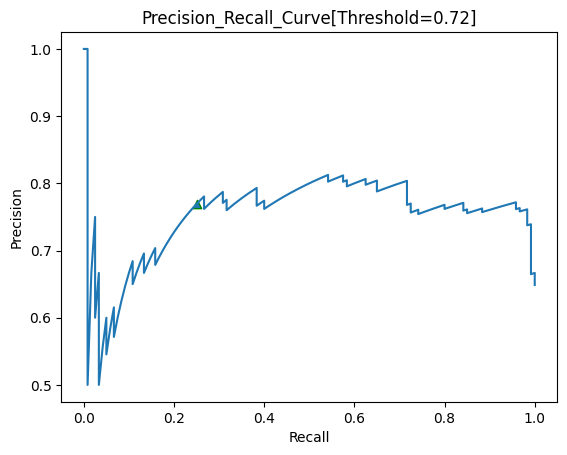

In [90]:
from sklearn.metrics import precision_recall_curve
precision,recall,thresholds = precision_recall_curve(y_test,y_prob)
y_pred = predict_with_threshold(final_model,x_test_ptf_scl)
precision_thr = precision_score(y_test,y_pred)
recall_thr = recall_score(y_test,y_pred)

plt.plot(recall,precision)      # lineplot shows trend b/w precision and recall of our final_model when precision on different recall_values
plt.scatter(recall_thr,precision_thr,marker='^',edgecolors='green')   # Create single dot at precision_recall_curve where 
plt.title('Precision_Recall_Curve[Threshold=0.72]')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [91]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[56  9]
 [90 30]]
              precision    recall  f1-score   support

           0       0.38      0.86      0.53        65
           1       0.77      0.25      0.38       120

    accuracy                           0.46       185
   macro avg       0.58      0.56      0.45       185
weighted avg       0.63      0.46      0.43       185



### *For Government Banks*/ Private Banks [Most balanced considering both growth and low risky approvals] 
-----------------------------------

In [92]:
# def function to automate this :
def predict_with_threshold_balanced(final_model,test_data):
    y_prob = final_model.predict_proba(test_data)[:, 1]
    y_pred = (y_prob >= 0.66).astype(int)
    return y_pred

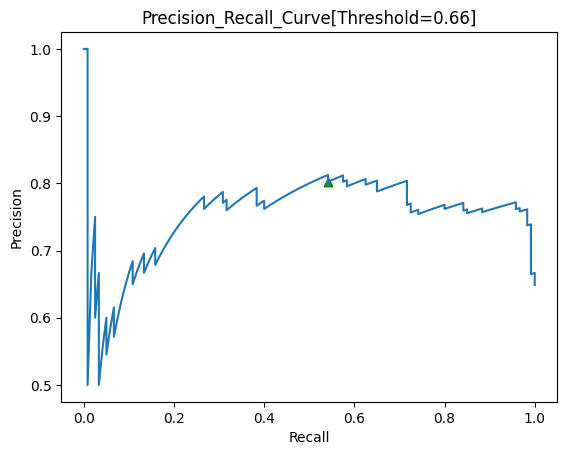

In [93]:
precision,recall,thresholds = precision_recall_curve(y_test,y_prob)
y_pred = predict_with_threshold_balanced(final_model,x_test_ptf_scl)
precision_thr = precision_score(y_test,y_pred)
recall_thr = recall_score(y_test,y_pred)

plt.plot(recall,precision)      # lineplot shows trend b/w precision and recall of our final_model when precision on different recall_values
plt.scatter(recall_thr,precision_thr,marker='^',edgecolors='green')   # Create single dot at precision_recall_curve where 
plt.title('Precision_Recall_Curve[Threshold=0.66]')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [94]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[49 16]
 [55 65]]
              precision    recall  f1-score   support

           0       0.47      0.75      0.58        65
           1       0.80      0.54      0.65       120

    accuracy                           0.62       185
   macro avg       0.64      0.65      0.61       185
weighted avg       0.69      0.62      0.62       185



Business Recommendation :

- Reduces risky loan approvals to only 16 cases, lowering financial exposure.

- Maintains recall, ensuring most reliable customers are still approved.

- Provides a balanced trade-off between risk control and business growth.

- Delivers stable overall performance with 80% precision.

With this threshold(0.66), the model supports smarter lending decisions — protecting the bank while continuing to serve genuine customers confidently.

### *KNN Model* Hyperparameter_tuning & threshold shifting
------------------------------------------------------

In [96]:
x_train1,y_train=x_train_maxab_scl,y_train

In [97]:
param_grid = {
    'n_neighbors': range(5, 60),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]}
grid = GridSearchCV(KNeighborsClassifier(),param_grid,scoring='precision',cv=5)
grid.fit(x_train1, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
for i in [0.65,0.66,0.67,0.68,0.69,0.70,0.63,0.60]:
    best_model = grid.best_estimator_
    y_prob = best_model.predict_proba(x_test_maxab_scl)[:,1]
    y_pred = (y_prob > i).astype(int)
    print(f"Threshold : {i}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best CV Score: 0.8095704295704296
Threshold : 0.65
[[31 34]
 [24 96]]
              precision    recall  f1-score   support

           0       0.56      0.48      0.52        65
           1       0.74      0.80      0.77       120

    accuracy                           0.69       185
   macro avg       0.65      0.64      0.64       185
weighted avg       0.68      0.69      0.68       185

Threshold : 0.66
[[31 34]
 [25 95]]
              precision    recall  f1-score   support

           0       0.55      0.48      0.51        65
           1       0.74      0.79      0.76       120

    accuracy                           0.68       185
   macro avg       0.65      0.63      0.64       185
weighted avg       0.67      0.68      0.67       185

Threshold : 0.67
[[32 33]
 [27 93]]
              precision    recall  f1-score   support

           0       0.54      0.49      0.52        65
     

In [98]:
param_grid = {
    'n_neighbors': range(5, 60),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]   # p=1 → Manhattan, p=2 → Euclidean
    }
grid = GridSearchCV(KNeighborsClassifier(),param_grid,scoring='recall',cv=5)
grid.fit(x_train1,y_train)

print("Best Parameters:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

for i in [0.65,0.66,0.67,0.68,0.69,0.70,0.63,0.60]:
    best_model = grid.best_estimator_
    y_prob = best_model.predict_proba(x_test_maxab_scl)[:,1]
    y_pred = (y_prob > i).astype(int)
    print(f"Threshold : {i}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
#0.7 threshold best choice

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 35, 'p': 1, 'weights': 'uniform'}
Best CV Score: 1.0
Threshold : 0.65
[[ 24  41]
 [  2 118]]
              precision    recall  f1-score   support

           0       0.92      0.37      0.53        65
           1       0.74      0.98      0.85       120

    accuracy                           0.77       185
   macro avg       0.83      0.68      0.69       185
weighted avg       0.81      0.77      0.73       185

Threshold : 0.66
[[ 27  38]
 [  6 114]]
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        65
           1       0.75      0.95      0.84       120

    accuracy                           0.76       185
   macro avg       0.78      0.68      0.69       185
weighted avg       0.77      0.76      0.74       185

Threshold : 0.67
[[ 27  38]
 [  6 114]]
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        65
        

##### After evaluating multiple threshold values, 0.7 is selected as the optimal decision threshold.
- Precision(class 1) : 77%
- Strong Recall_score : 91
- Overall accuracy : 76
- FP : 33, FN : 11

In [99]:
KNN_Final_Model = best_model # changing model name

In [100]:
# def function for easy use, we just have to put clean data without scalling with no manually threshold adjustment.
def predict_with_KNN(test_data):
    test_data_scl = maxab_scl.transform(test_data)
    y_prob = KNN_Final_Model.predict_proba(test_data_scl)[:, 1]
    y_pred = (y_prob >= 0.7).astype(int)
    return y_pred

Precision_recall_curve for KNN

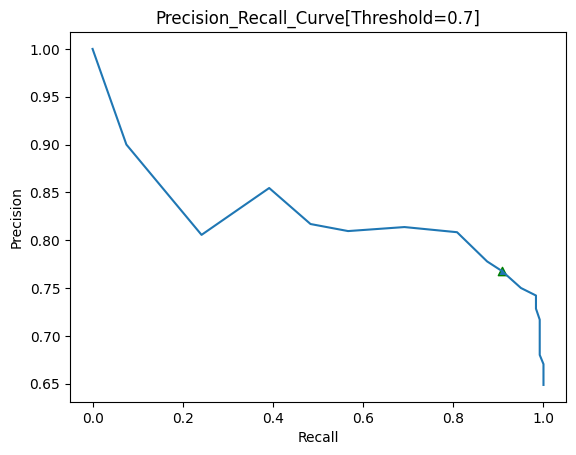

In [102]:
precision,recall,thresholds = precision_recall_curve(y_test,y_prob)
y_pred = predict_with_KNN(x_test)
precision_thr = precision_score(y_test,y_pred)
recall_thr = recall_score(y_test,y_pred)
plt.plot(recall,precision)      
plt.scatter(recall_thr,precision_thr,marker='^',edgecolors='green')
plt.title('Precision_Recall_Curve[Threshold=0.7]')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

### *We have three final models*:
##### - if wrong_approvals is most important concern......................................|use predict_with_threshold (def)/ model_logistic with 0.72 threshold
##### - if balanced_approach (Growth with less wrong approvals).................|use predict_with_threshold_balanced (def)/ model_logistic with 0.66 threshold
##### - if Same_balanced_approach but FP slightly up but high recall...........|use predict_with_KNN (def) / 0.7 threshold

This project demonstrates how data-driven decision-making can strengthen risk control while supporting sustainable business growth — turning raw data into smarter, safer lending decisions.

In this study, three classification models were evaluated — Logistic Regression, K-Nearest Neighbors, and Decision Tree. Among these, Logistic Regression demonstrated the most stable and reliable performance. No additional models were explored beyond these three within the scope of this analysis.